In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.model_selection import LeaveOneOut,KFold
from itertools import product

In [10]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
data = data.drop(columns = ['No.','Ref', 'Biomass','Catalyst'])

X= data.drop(['Gas yield','Oil yield', 'Char yield'], axis =1, inplace = False)
y = data['Gas yield']

In [11]:
para = {
    'n_estimators': [100,200],
    'max_depth': [5,7],
    'learning_rate': [0.1,0.01],
    'num_leaf': [15,31]
}

para_comb = list(product(para['n_estimators'],para['max_depth'],para['learning_rate'],para['num_leaf']))

In [12]:
from numpy.random.mtrand import random
mse_hist =[]
best_para = None
bmse = float('inf')


for n_estimators,max_depth,learning_rate,num_leaf in para_comb:
    model = LGBMRegressor(n_estimators = n_estimators,
                          max_depth = max_depth,
                          learning_rate= learning_rate,
                          num_leaves=num_leaf,verbose = -1,random_state = 42)
    loo = LeaveOneOut()

    mse_hist =[]
    for train_idx,test_idx in loo.split(y):
      x_train,y_train,x_test,y_test=X.iloc[train_idx],y.iloc[train_idx],X.iloc[test_idx],y.iloc[test_idx]

      model.fit(x_train,y_train)
      y_pred =model.predict(x_test)
      mse =mean_squared_error(y_test,y_pred)
      mse_hist.append(mse)

    mse= np.mean(mse_hist)

    if mse < bmse:
      bmse = mse
      best_para= {
                   'n_estimators' : n_estimators,
                    'max_depth' :max_depth,
                    'learning_rate' : learning_rate,
                    'num_leaves' :num_leaf

      }


{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'num_leaves': 15}
MSE: 19.70606236153246
MAE: 3.05729914249431
R2: 0.9149139159114396


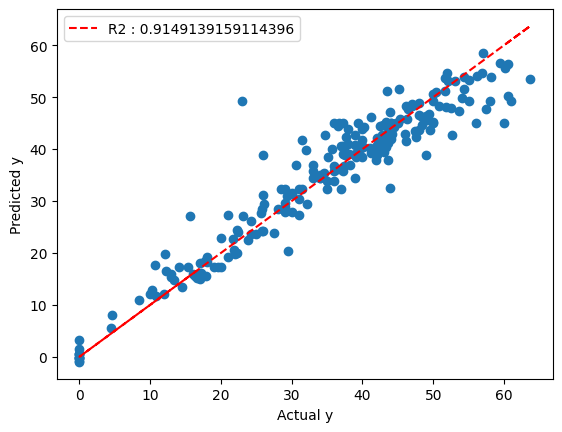

In [13]:
best_model = LGBMRegressor(**best_para,verbose =-1,random_state=42)

best_model.fit(X,y)
y_pred = best_model.predict(X)

mse = mean_squared_error(y,y_pred)
mae = mean_absolute_error(y,y_pred)
r2 = r2_score(y,y_pred)

print(best_para)
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')

plt.plot(y,y,'r--',label = 'Ideal')
plt.scatter(y,y_pred,label= 'Predicted values')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.legend([f'R2 : {r2}'])
plt.show()